# Edge IIoT - Anomaly Detection - Isolation Forest

## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix
)

from src.preprocessing import Utils, Resamplers, Filters
from src.config import DATASETS, SEED

np.random.seed(SEED)
print(f'NumPy seed set to {SEED}')

NumPy seed set to 42


## 1. Data Loading

In [2]:
dataset_name = 'edge_iiot'
config       = DATASETS[dataset_name]

filename = 'DL-EdgeIIoT-dataset_clean'
csv_path = config['processed_path'] / f'{filename}.pkl'

print('Loading dataset...')
df = pd.read_pickle(csv_path)
print(f'Dataset shape : {df.shape}')

Loading dataset...
Dataset shape : (2158750, 62)


## 2. Pre-processing 

In [3]:
cols_to_drop = [
    'frame.time.delta', 'frame.time.order',
    *[c for c in df.columns if c.startswith('ip.src_category') or c.startswith('ip.dst_category')]
]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [4]:
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline([
    ("filter_invalid_time", Filters.ValidTimeFilter()),
    ("drop_categorical",    Filters.CategoricalDropper()),
    ("train_test_split",    Utils.AnomalyTrainTestSplitter()),
    ("undersample",         Resamplers.ClassPresenceUndersampler()),
    ('xysplit',             Utils.SplitExtractor())
])

X_train, X_test, y_train, y_test, _, y_mc_test, X_val, y_val, _  = preprocessing_pipeline.fit_transform(df)


  [ValidTimeFilter] Dropped 122,596 rows  →  (2036154, 52)
  [CategoricalDropper] Dropped 7 categorical columns: ['http.file_data', 'http.referer', 'http.request.path', 'http.request.uri.query', 'http.request.version', 'mqtt.msg', 'proto']  →  (2036154, 45)
  [AnomalyTrainTestSplitter]
    Train: 1,130,949 (Normal only)
    Val:   301,734 (161,564 Normal + 140,170 attacks)
    Test:  603,471 (323,129 Normal + 280,342 attacks)
  [ClassPresenceUndersampler] Split: 'train' | Single class ('Normal') | Old Count: 1,130,949 | New Count: 565,474
  [ClassPresenceUndersampler] Split: 'val' | Old Count: 301,734 | New Count: 214,124
  [ClassPresenceUndersampler] Split: 'test' | Old Count: 603,471 | New Count: 428,250
  [SplitExtractor] X_train: (565474, 43)  |  X_test: (428250, 43)  |  y_bin_train: (565474,) | y_15c_train: (565474,) | y_bin_test: (428250,) | y_15c_test: (428250,)
  [SplitExtractor] X_val: (214124, 43) | y_bin_val: (214124,) | y_15c_val: (214124,)


In [5]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Train scaled : {X_train_scaled.shape}')
print(f'Val   scaled : {X_val_scaled.shape}'  )
print(f'Test  scaled : {X_test_scaled.shape}' )

Train scaled : (565474, 43)
Val   scaled : (214124, 43)
Test  scaled : (428250, 43)


In [6]:
actual_rate = (y_train == 1).mean()
print(f"Attack rate in training pool:{actual_rate*100:.2f}%")

Attack rate in training pool:0.00%


## 3. Isolation Forest (IF) Definition

### Threshold Function

In [7]:
def threshold_from_train_quantile(train_scores, q=0.95):
    return np.quantile(train_scores, q)

### Score Functions

In [8]:
from typing import Callable


def if_score(model: IsolationForest, x: np.ndarray) -> np.ndarray:
    """Standard Isolation-Forest anomaly score (higher = more anomalous)."""
    return -model.score_samples(x)


def if_decision(model: IsolationForest, x: np.ndarray) -> np.ndarray:
    """Negative `decision_function`. Same ranking as `if_score`, different offset."""
    return -model.decision_function(x)


def if_path_length(model: IsolationForest, x: np.ndarray) -> np.ndarray:
    """Mean isolation path length across all trees, sign-flipped so that
    shorter paths (= more anomalous) correspond to higher scores."""
    depths = np.zeros(x.shape[0], dtype=float)
    for est, feats in zip(model.estimators_, model.estimators_features_):
        leaves = est.apply(x[:, feats])
        node_depth = np.zeros(est.tree_.node_count, dtype=int)
        stack = [(0, 0)]
        while stack:
            node, depth = stack.pop()
            node_depth[node] = depth
            left, right = est.tree_.children_left[node], est.tree_.children_right[node]
            if left != right:        # internal node
                stack.append((left,  depth + 1))
                stack.append((right, depth + 1))
        depths += node_depth[leaves]
    depths /= len(model.estimators_)
    return -depths

In [9]:
SCORE_FUNCTIONS: dict[str, Callable[[IsolationForest, np.ndarray], np.ndarray]] = {
    "score": if_score,
    "decision": if_decision,
    "path_length": if_path_length,
}

### Modular Detector

In [ ]:
class IsolationForestAnomalyDetector:
    """Isolation-Forest anomaly detector with configurable forest geometry."""

    def __init__(
        self,
        n_estimators: int           = 100,
        max_samples: int | str | float = "auto",
        max_features: float         = 1.0,
        contamination: float | str  = "auto",
        bootstrap: bool             = False,
        n_jobs: int                 = -1,
        random_state: int           = SEED,
    ):
        self.n_estimators  = n_estimators
        self.max_samples   = max_samples
        self.max_features  = max_features
        self.contamination = contamination
        self.bootstrap     = bootstrap
        self.n_jobs        = n_jobs
        self.random_state  = random_state
        self._if = IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            max_features=max_features,
            contamination=contamination,
            bootstrap=bootstrap,
            n_jobs=n_jobs,
            random_state=random_state,
        )

    @property
    def estimators_(self):
        return self._if.estimators_

    @property
    def n_features_in_(self):
        return self._if.n_features_in_

    def fit(self, X: np.ndarray) -> "IsolationForestAnomalyDetector":
        self._if.fit(X)
        return self

    def anomaly_score(
        self,
        x: np.ndarray,
        score_fn: str | Callable[[IsolationForest, np.ndarray], np.ndarray] = "score",
    ) -> np.ndarray:
        """Per-sample anomaly score (higher = more anomalous)."""
        if isinstance(score_fn, str):
            try:
                score_fn = SCORE_FUNCTIONS[score_fn]
            except KeyError:
                raise ValueError(
                    f"Unknown score_fn '{score_fn}'. "
                    f"Choose from {list(SCORE_FUNCTIONS)} or pass a callable."
                )
        return score_fn(self._if, np.asarray(x))

### Fitting Function

In [ ]:
def fit_isolation_forest(
    model,
    X_train,
    verbose: bool = True,
):
    """Fit an IsolationForestAnomalyDetector on the normal-only training pool. """
    n_train = len(X_train)
    if verbose:
        print(
            f"Fitting Isolation Forest (n_estimators={model.n_estimators}, "
            f"max_samples={model.max_samples}, max_features={model.max_features}) "
            f"on {n_train:,} normal samples (input_dim={X_train.shape[1]})..."
        )
    t0 = time.time()
    model.fit(X_train)
    fit_time = time.time() - t0

    history = {
        "n_estimators": int(model.n_estimators),
        "max_samples":  model.max_samples,
        "fit_time":     fit_time,
    }

    if verbose:
        print(
            f"  Fitted in {fit_time:.1f}s | "
            f"n_estimators={history['n_estimators']} | "
            f"max_samples={history['max_samples']}"
        )

    return history

## 4. IF Experiments

### Training Data

In [ ]:
X_if_train = X_train_scaled

X_val_normal_scaled = X_val_scaled[y_val == 0]   # normal-only val for thresholding
X_if_val   = X_val_normal_scaled
X_if_test  = X_test_scaled

print(f'IF train  : {X_if_train.shape} (normal-only pool, undersampled)')
print(f'IF val    : {X_if_val.shape} (normal-only, thresholding)')
print(f'IF test   : {X_if_test.shape}')

IF train  : (565474, 43) (normal-only pool, undersampled)
IF val    : (80782, 43) (normal-only, thresholding)
IF test   : (428250, 43)


### Exp function

In [ ]:
def run_if_experiment(
    name,
    n_estimators,
    *,
    max_samples="auto",
    max_features=1.0,
    contamination="auto",
    bootstrap=False,
    score_fns=("score",),
    threshold_fpr=0.01,
    seed=SEED,
    verbose=False,
):
    """Build, fit and evaluate one Isolation Forest configuration."""
    np.random.seed(seed)

    model = IsolationForestAnomalyDetector(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        bootstrap=bootstrap,
        random_state=seed,
    )

    n_params = n_estimators   # one tree per estimator; rough capacity proxy

    t0 = time.time()
    history = fit_isolation_forest(model, X_if_train, verbose=verbose)
    fit_time = time.time() - t0

    per_loss = {}
    for sf_name in score_fns:
        val_scores  = model.anomaly_score(X_if_val,  score_fn=sf_name)
        test_scores = model.anomaly_score(X_if_test, score_fn=sf_name)

        thr = threshold_from_train_quantile(val_scores, q=1.0 - threshold_fpr)
        val_fpr = float((val_scores >= thr).mean())   # realised FPR on normal val

        auroc = roc_auc_score(y_test, test_scores)
        auprc = average_precision_score(y_test, test_scores)

        y_pred = (test_scores >= thr).astype(int)
        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        per_loss[sf_name] = dict(
            AUROC=auroc,
            AUPRC=auprc,
            F1=rep["1"]["f1-score"],
            Precision=rep["1"]["precision"],
            Recall=rep["1"]["recall"],
            threshold=float(thr),
            val_fpr=val_fpr,
            y_pred=y_pred,
        )

    return dict(
        name=name,
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        bootstrap=bootstrap,
        n_params=n_params,
        fit_time=fit_time,
        history=history,
        per_loss=per_loss,
        model=model,
    )

### Configs (MODIFYME)

In [ ]:
IF_CONFIGS = [
    # Baseline
    dict(name="if-default",  n_estimators=100, max_samples="auto", max_features=1.0),

    # Number of trees sweep
    dict(name="if-n50",      n_estimators=50,  max_samples="auto", max_features=1.0),
    dict(name="if-n200",     n_estimators=200, max_samples="auto", max_features=1.0),
    dict(name="if-n400",     n_estimators=400, max_samples="auto", max_features=1.0),

    # Sub-sample size sweep
    dict(name="if-ss512",    n_estimators=100, max_samples=512,   max_features=1.0),
    dict(name="if-ss2048",   n_estimators=100, max_samples=2048,  max_features=1.0),

    # Feature sub-sampling (Extended IF-style)
    dict(name="if-feat0.5",  n_estimators=100, max_samples="auto", max_features=0.5),
    dict(name="if-feat0.75", n_estimators=100, max_samples="auto", max_features=0.75),
]

EVAL_LOSSES = ["score", "decision", "path_length"]
THRESHOLD_FPR = 0.05    # target false-positive rate on normal traffic

### Execution

In [15]:
arch_runs = {}
for cfg in IF_CONFIGS:
    print(f"\n--- {cfg['name']} | n_estimators={cfg['n_estimators']} "
          f"max_samples={cfg['max_samples']} max_features={cfg['max_features']} ---")
    run = run_if_experiment(
        cfg["name"], cfg["n_estimators"],
        max_samples=cfg["max_samples"],
        max_features=cfg["max_features"],
        score_fns=EVAL_LOSSES,
        threshold_fpr=THRESHOLD_FPR,
        verbose=True,
    )
    arch_runs[cfg["name"]] = run
    m = run["per_loss"]["score"]
    print(f"  n_estimators={run['n_estimators']}  "
          f"max_samples={run['max_samples']}  "
          f"max_features={run['max_features']}  "
          f"AUROC(score)={m['AUROC']:.4f}  F1(score)={m['F1']:.4f}  "
          f"Recall(score)={m['Recall']:.4f}  val_FPR={m['val_fpr']:.3f}")


--- if-default | n_estimators=100 max_samples=auto max_features=1.0 ---
Fitting Isolation Forest (n_estimators=100, max_samples=auto, max_features=1.0) on 565,474 normal samples (input_dim=43)...
  Fitted in 0.6s | n_estimators=100 | max_samples=auto
  n_estimators=100  max_samples=auto  max_features=1.0  AUROC(score)=0.4871  F1(score)=0.1590  Recall(score)=0.0897  val_FPR=0.064

--- if-n50 | n_estimators=50 max_samples=auto max_features=1.0 ---
Fitting Isolation Forest (n_estimators=50, max_samples=auto, max_features=1.0) on 565,474 normal samples (input_dim=43)...
  Fitted in 0.2s | n_estimators=50 | max_samples=auto
  n_estimators=50  max_samples=auto  max_features=1.0  AUROC(score)=0.4557  F1(score)=0.1610  Recall(score)=0.0927  val_FPR=0.098

--- if-n200 | n_estimators=200 max_samples=auto max_features=1.0 ---
Fitting Isolation Forest (n_estimators=200, max_samples=auto, max_features=1.0) on 565,474 normal samples (input_dim=43)...
  Fitted in 1.3s | n_estimators=200 | max_sample

## 5. Exp Comparison

In [16]:
METRIC_KEYS = ["AUROC", "AUPRC", "F1", "Precision", "Recall", "val_fpr"]


def _metrics_only(d):
    return {k: d[k] for k in METRIC_KEYS}


# ---------------------------------------------------------------
arch_df = (
    pd.DataFrame([
        dict(Model=r["name"],
             n_estimators=r["n_estimators"],
             max_samples=str(r["max_samples"]),
             max_features=r["max_features"],
             n_params=r["n_params"],
             fit_time=r["fit_time"],
             **_metrics_only(r["per_loss"]["score"]))
        for r in arch_runs.values()
    ])
    .set_index("Model")
)

# ---------------------------------------------------------------
loss_df = pd.DataFrame([
    dict(Model=r["name"], loss=sf_name, **_metrics_only(metrics))
    for r in arch_runs.values()
    for sf_name, metrics in r["per_loss"].items()
])

pivot_auroc = loss_df.pivot(index="Model", columns="loss", values="AUROC")
pivot_f1    = loss_df.pivot(index="Model", columns="loss", values="F1")

print("=== Forest sweep (score scoring, unsupervised threshold) ===")
print(arch_df.sort_values("AUROC", ascending=False)
            .to_string(float_format="{:.4f}".format))
print("\n=== AUROC by configuration x score function (threshold-free) ===")
print(pivot_auroc.to_string(float_format="{:.4f}".format))

=== Forest sweep (score scoring, unsupervised threshold) ===
             n_estimators max_samples  max_features  n_params  fit_time  AUROC  AUPRC     F1  Precision  Recall  val_fpr
Model                                                                                                                   
if-ss2048             100        2048        1.0000       100    1.2975 0.5266 0.6435 0.1484     0.6676  0.0835   0.0689
if-ss512              100         512        1.0000       100    0.7740 0.5194 0.6533 0.1652     0.6864  0.0939   0.0709
if-default            100        auto        1.0000       100    0.6059 0.4871 0.6313 0.1590     0.6991  0.0897   0.0638
if-n400               400        auto        1.0000       400    2.2580 0.4775 0.6267 0.1582     0.7065  0.0891   0.0611
if-n200               200        auto        1.0000       200    1.2540 0.4757 0.6266 0.1587     0.7211  0.0892   0.0566
if-n50                 50        auto        1.0000        50    0.2246 0.4557 0.6193 0.1610

### Score Distributions

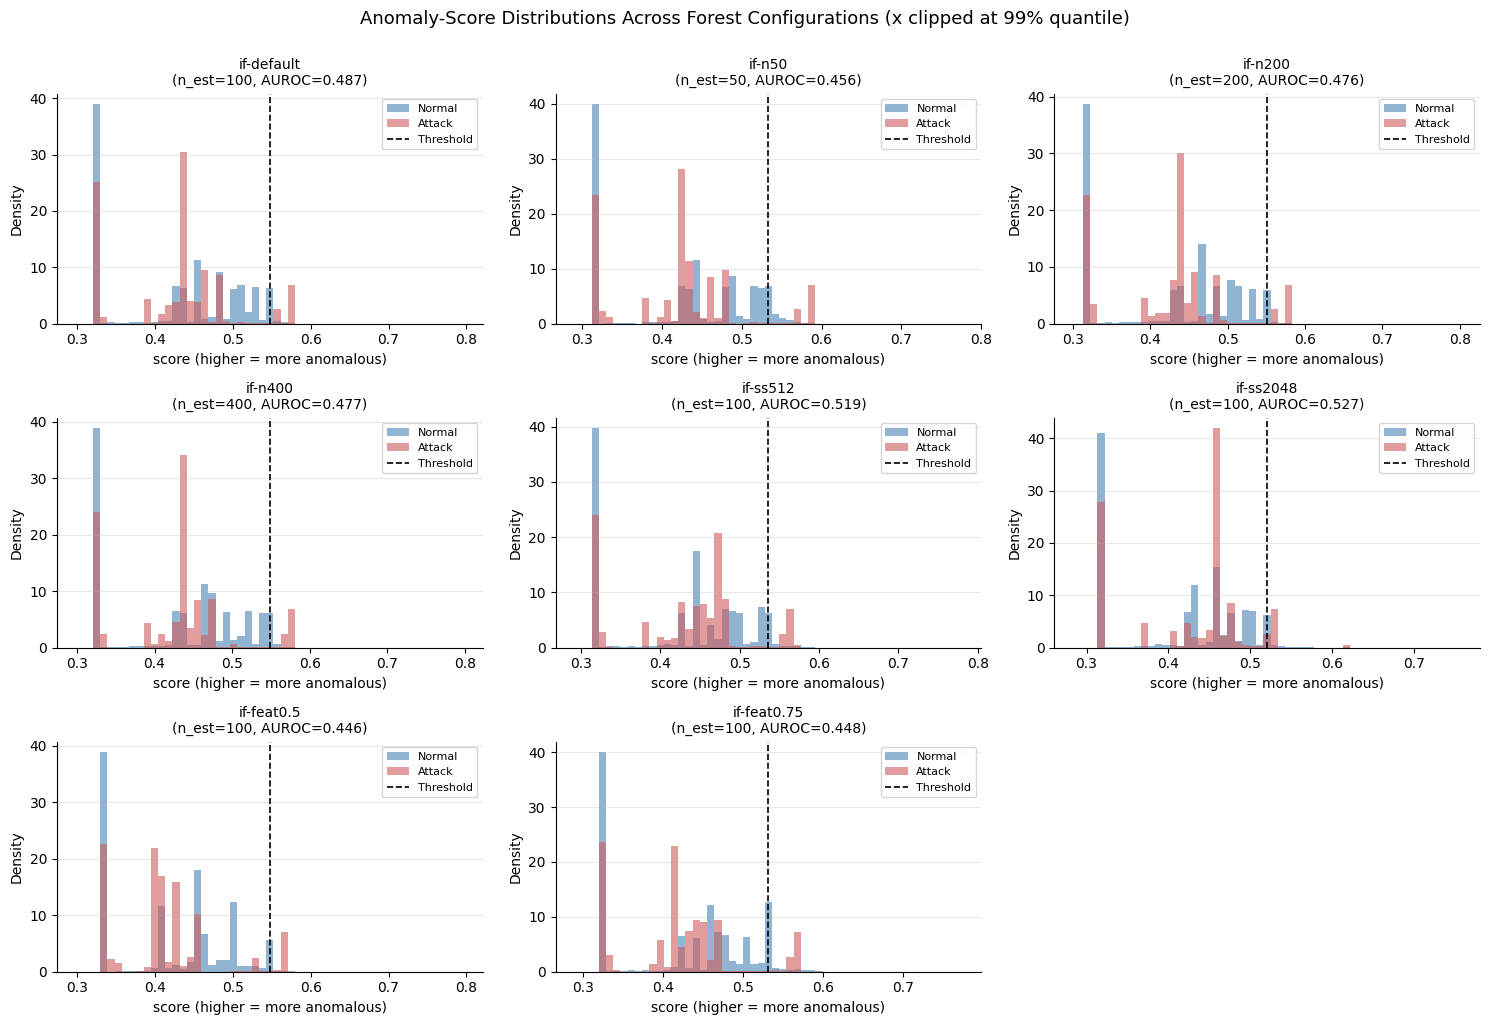

In [ ]:
SCORE_DIST_FN = "score"
CLIP_Q        = 0.99   # display upper bound = this quantile of the scores

n_runs = len(arch_runs)
ncols  = 3
nrows  = int(np.ceil(n_runs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.4 * nrows), squeeze=False)
for ax, (name, r) in zip(axes.flat, arch_runs.items()):
    scores = r["model"].anomaly_score(X_if_test, score_fn=SCORE_DIST_FN)
    info   = r["per_loss"][SCORE_DIST_FN]

    xmax = max(np.quantile(scores, CLIP_Q), info["threshold"] * 1.5)
    xmin = min(np.quantile(scores, 1 - CLIP_Q), info["threshold"] * 0.5)
    bins = np.linspace(xmin, xmax, 60)
    clipped = np.clip(scores, xmin, xmax)

    ax.hist(clipped[y_test == 0], bins=bins, color="steelblue",
            alpha=0.6, label="Normal", density=True)
    ax.hist(clipped[y_test == 1], bins=bins, color="indianred",
            alpha=0.6, label="Attack", density=True)
    ax.axvline(info["threshold"], color="black", ls="--", lw=1.2, label="Threshold")
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"{name}\n(n_est={r['n_estimators']}, "
                 f"AUROC={info['AUROC']:.3f})", fontsize=10)
    ax.set_xlabel(f"{SCORE_DIST_FN} (higher = more anomalous)")
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes.flat[n_runs:]:
    ax.set_visible(False)

fig.suptitle("Anomaly-Score Distributions Across Forest Configurations "
             f"(x clipped at {CLIP_Q:.0%} quantile)", fontsize=13, y=1.0)
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Trees vs Metrics

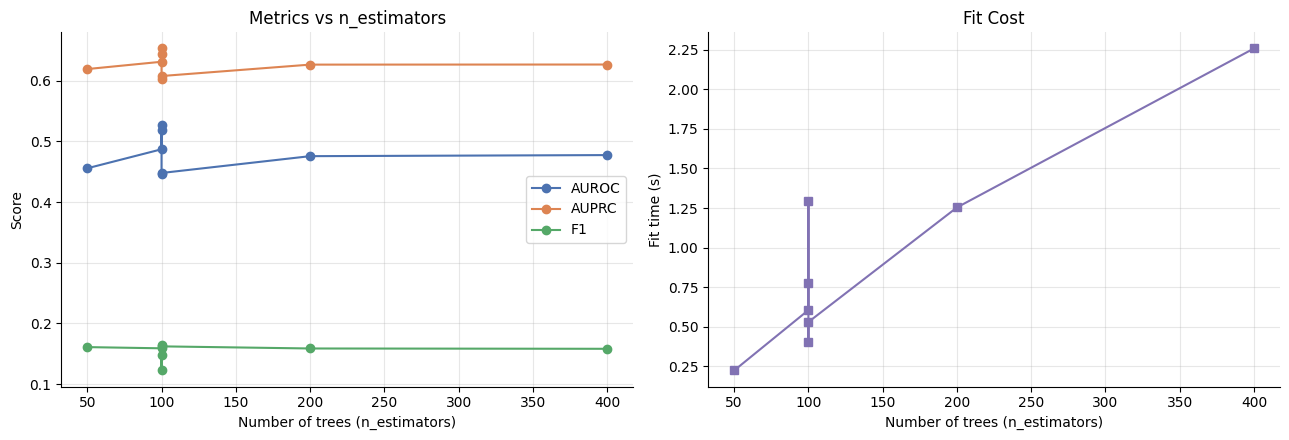

In [18]:
metrics_plot = ["AUROC", "AUPRC", "F1"]
palette      = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (Left) detection metrics vs number of trees (only configs with default
# max_samples/max_features to keep the axis meaningful)
g_n = arch_df.sort_values("n_estimators")
for m, c in zip(metrics_plot, palette):
    axes[0].plot(g_n["n_estimators"], g_n[m], marker="o", color=c, label=m)
axes[0].set_xlabel("Number of trees (n_estimators)")
axes[0].set_ylabel("Score")
axes[0].set_title("Metrics vs n_estimators")
axes[0].grid(alpha=0.3)
axes[0].legend()

# (Right) fit cost vs number of trees
axes[1].plot(g_n["n_estimators"], g_n["fit_time"], marker="s", color="#8172B3")
axes[1].set_xlabel("Number of trees (n_estimators)")
axes[1].set_ylabel("Fit time (s)")
axes[1].set_title("Fit Cost")
axes[1].grid(alpha=0.3)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Comparison Score Functions

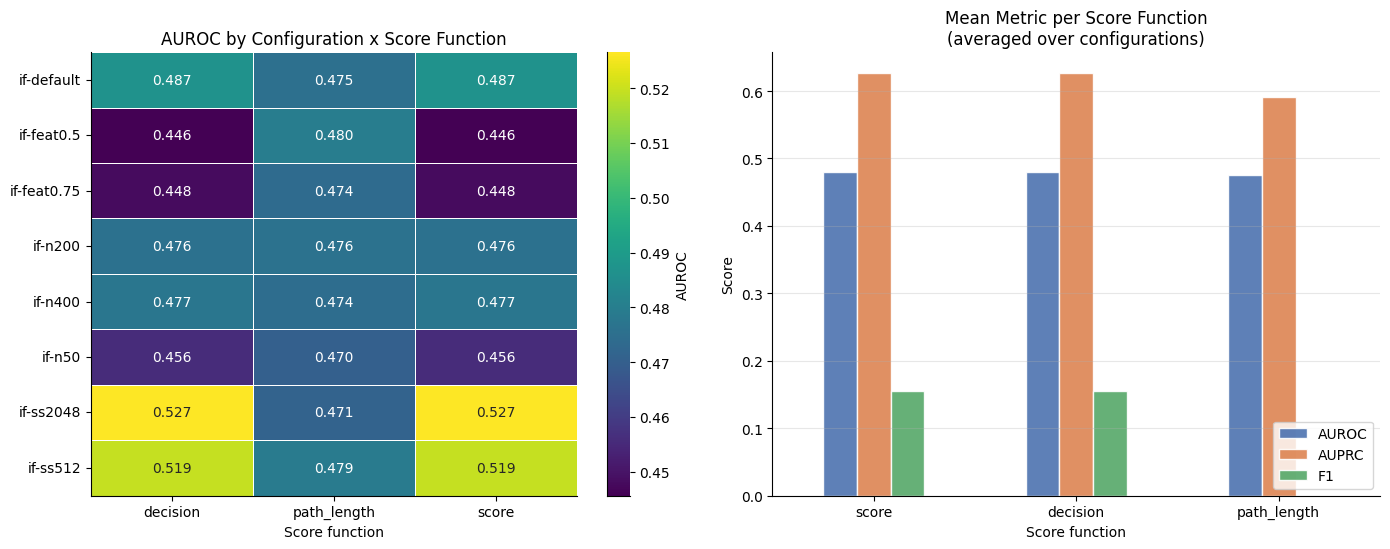

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(4.0, len(arch_runs) * 0.7)))

# ---------------------------------------------------------------
# (Left) AUROC heatmap
sns.heatmap(
    pivot_auroc, annot=True, fmt=".3f", cmap="viridis",
    linewidths=0.5, ax=axes[0], cbar_kws={"label": "AUROC"},
)
axes[0].set_title("AUROC by Configuration x Score Function")
axes[0].set_xlabel("Score function")
axes[0].set_ylabel("")

# ---------------------------------------------------------------
# (Right) Mean metric by score function (averaged over configurations)
mean_by_loss = loss_df.groupby("loss")[["AUROC", "AUPRC", "F1"]].mean()
mean_by_loss = mean_by_loss.loc[EVAL_LOSSES]          # keep declared order
mean_by_loss.plot(
    kind="bar", ax=axes[1],
    color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.9, edgecolor="white",
)
axes[1].set_title("Mean Metric per Score Function\n(averaged over configurations)")
axes[1].set_xlabel("Score function")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(loc="lower right")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Confusion Matrices

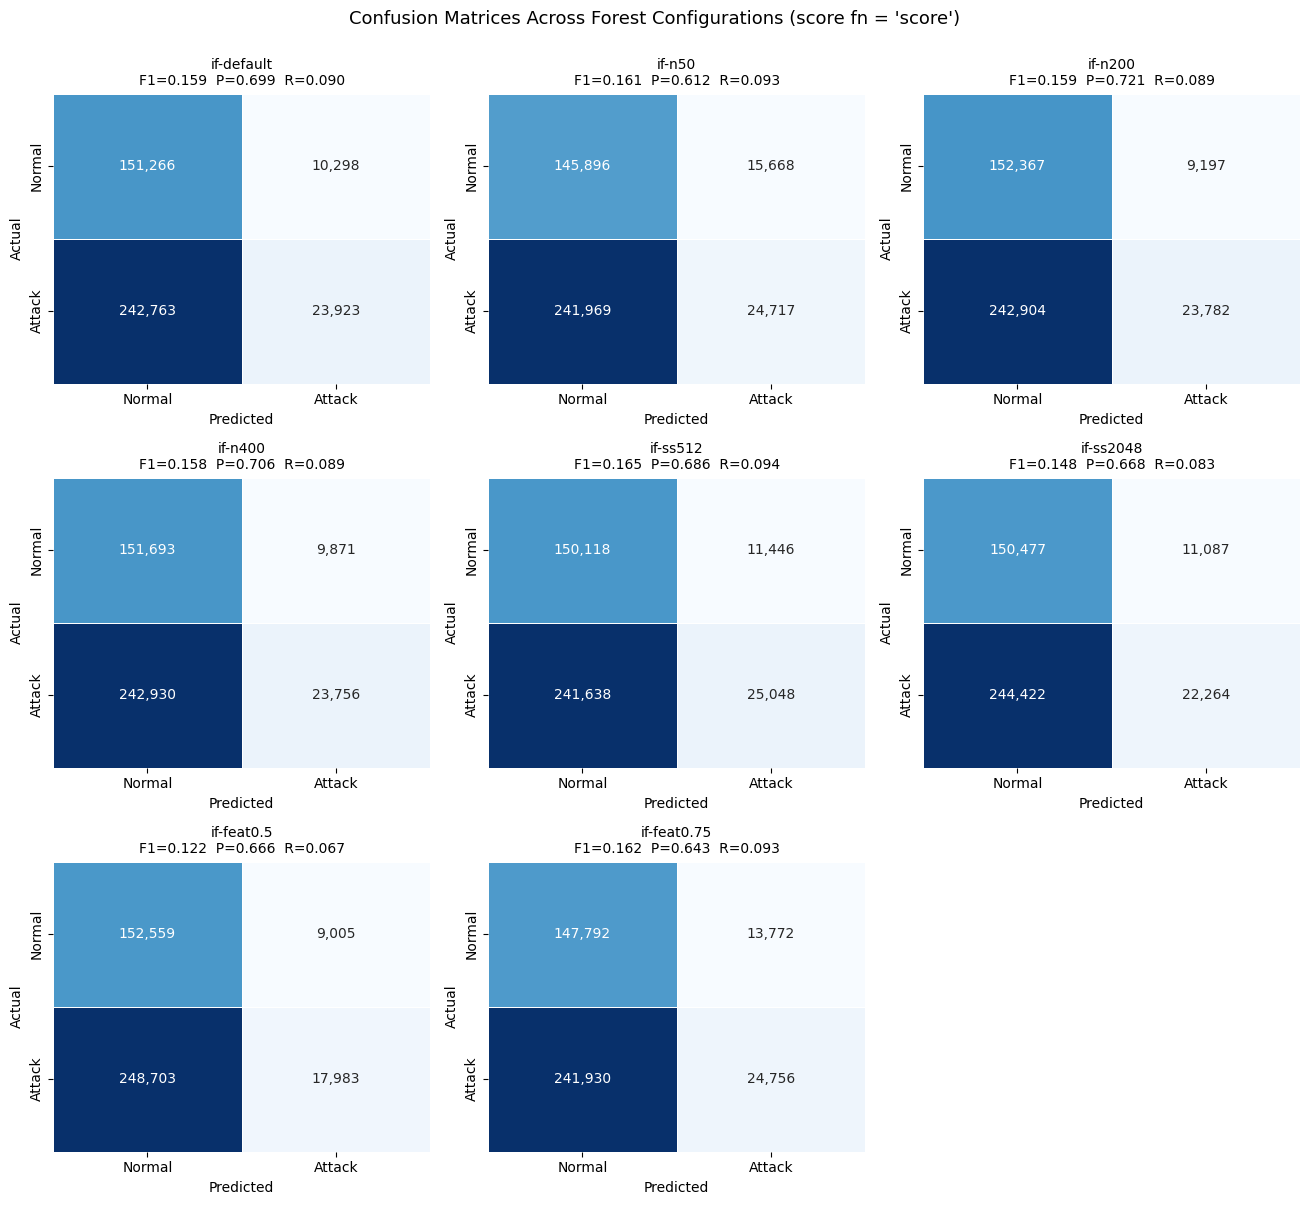

In [20]:
CM_SCORE_FN = "score"

cm_labels = ["Normal", "Attack"]
n_runs = len(arch_runs)
ncols  = 3
nrows  = int(np.ceil(n_runs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows), squeeze=False)
for ax, (name, r) in zip(axes.flat, arch_runs.items()):
    info = r["per_loss"][CM_SCORE_FN]
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
        xticklabels=cm_labels, yticklabels=cm_labels, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(
        f"{name}\nF1={info['F1']:.3f}  "
        f"P={info['Precision']:.3f}  R={info['Recall']:.3f}",
        fontsize=10,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes.flat[n_runs:]:
    ax.set_visible(False)

fig.suptitle(
    f"Confusion Matrices Across Forest Configurations (score fn = '{CM_SCORE_FN}')",
    fontsize=13, y=1.0,
)
plt.tight_layout()
plt.show()

## 6. Best IF

In [21]:
best_idx = loss_df["AUROC"].idxmax()
best = loss_df.loc[best_idx]
best_cfg = arch_runs[best["Model"]]
best_info = best_cfg["per_loss"][best["loss"]]

print("Best configuration by AUROC")
print(f"  Forest       : {best['Model']}  "
      f"(n_estimators={best_cfg['n_estimators']}, "
      f"max_samples={best_cfg['max_samples']}, "
      f"max_features={best_cfg['max_features']})")
print(f"  Score fn     : {best['loss']}")
print(f"  AUROC={best['AUROC']:.4f}  AUPRC={best['AUPRC']:.4f}")
print(f"  Operating point @ {THRESHOLD_FPR:.0%} target FPR "
      f"(normal-val FPR={best_info['val_fpr']:.3f}, threshold={best_info['threshold']:.4f}):")
print(f"    F1={best['F1']:.4f}  Precision={best['Precision']:.4f}  Recall={best['Recall']:.4f}")
print(f"  Params       : {best_cfg['n_params']:,}   "
      f"Fit time: {best_cfg['fit_time']:.1f}s")

Best configuration by AUROC
  Forest       : if-ss2048  (n_estimators=100, max_samples=2048, max_features=1.0)
  Score fn     : score
  AUROC=0.5266  AUPRC=0.6435
  Operating point @ 5% target FPR (normal-val FPR=0.069, threshold=0.5207):
    F1=0.1484  Precision=0.6676  Recall=0.0835
  Params       : 100   Fit time: 1.3s


### Confussion Matrixes per score function

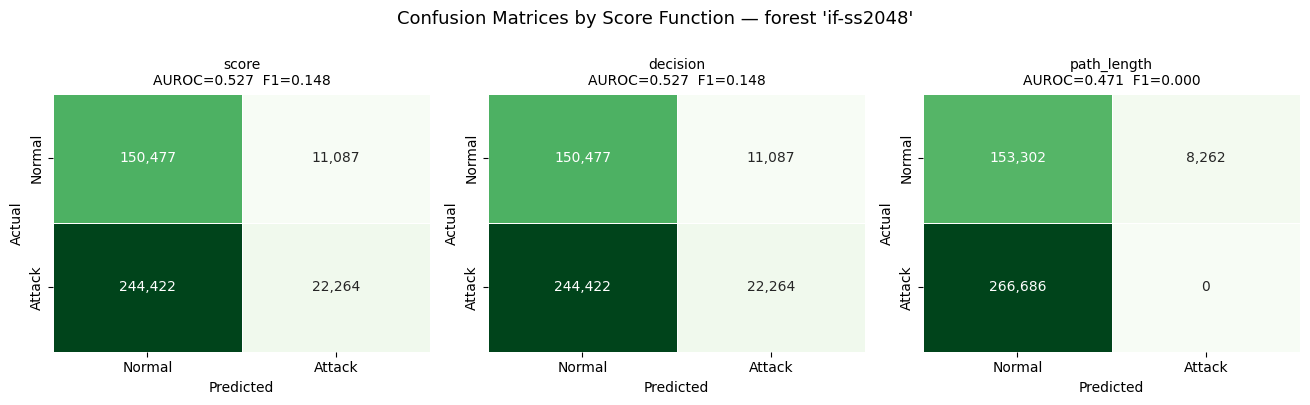

In [22]:
best_arch_name = arch_df["AUROC"].idxmax()
best_run = arch_runs[best_arch_name]

n_losses = len(EVAL_LOSSES)
ncols    = 3
nrows    = int(np.ceil(n_losses / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows), squeeze=False)
for ax, sf in zip(axes.flat, EVAL_LOSSES):
    info = best_run["per_loss"][sf]
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Greens", cbar=False,
        xticklabels=cm_labels, yticklabels=cm_labels, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(
        f"{sf}\nAUROC={info['AUROC']:.3f}  F1={info['F1']:.3f}",
        fontsize=10,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes.flat[n_losses:]:
    ax.set_visible(False)

fig.suptitle(
    f"Confusion Matrices by Score Function — forest '{best_arch_name}'",
    fontsize=13, y=1.0,
)
plt.tight_layout()
plt.show()

### Per-class detection rate

Per-class detection rate — best model: if-ss2048 / score (threshold @ 5% target FPR)

                Class   Kind  Support  Detected  Accuracy
             DDoS_TCP Attack    18840     17142    0.9099
        Port_Scanning Attack    14666      4523    0.3084
       Fingerprinting Attack      692        33    0.0477
           Ransomware Attack     7187       167    0.0232
             Backdoor Attack    16202       353    0.0218
                  XSS Attack    10381        18    0.0017
             Password Attack    31839         8    0.0003
Vulnerability_scanner Attack    31647         7    0.0002
            Uploading Attack    24175         5    0.0002
        SQL_injection Attack    32181         5    0.0002
            DDoS_HTTP Attack    31541         2    0.0001
            DDoS_ICMP Attack    47335         1    0.0000
               Normal Normal   161564     11087    0.9314

  Macro (per-class mean) accuracy : 0.1727
  Attack-only mean detection rate : 0.1095


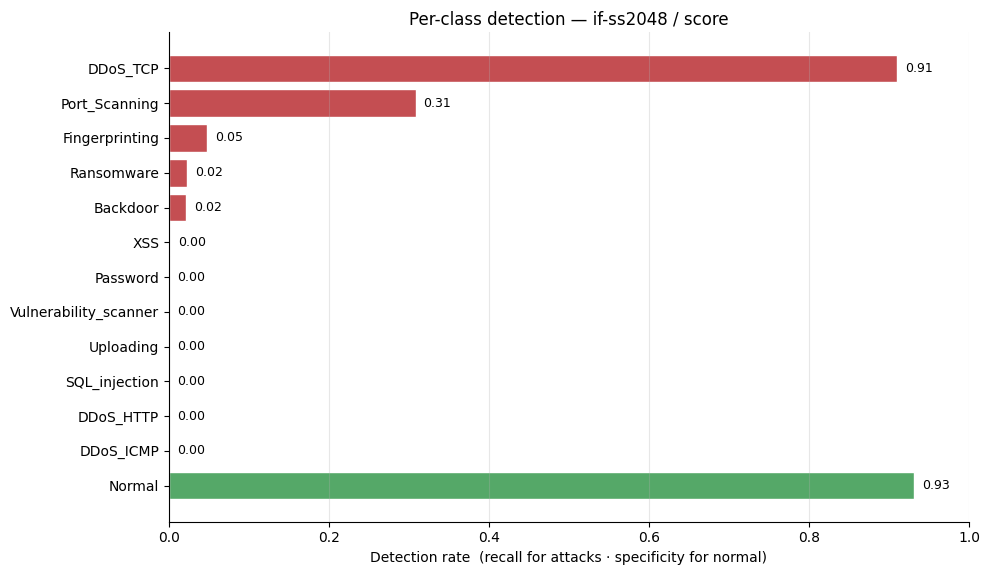

In [23]:
y_pred_best = best_info["y_pred"]
mc = np.asarray(y_mc_test)

rows = []
for cls in pd.unique(mc):
    mask = mc == cls
    n = int(mask.sum())
    is_attack = (y_test[mask] == 1).all()
    correct = y_pred_best[mask] == 1 if is_attack else y_pred_best[mask] == 0
    rows.append(dict(
        Class=str(cls),
        Kind="Attack" if is_attack else "Normal",
        Support=n,
        Detected=int((y_pred_best[mask] == 1).sum()),
        Accuracy=float(correct.mean()),
    ))

per_class_df = (
    pd.DataFrame(rows)
    .sort_values(["Kind", "Accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
#  Print
print(f"Per-class detection rate — best model: "
      f"{best['Model']} / {best['loss']} "
      f"(threshold @ {THRESHOLD_FPR:.0%} target FPR)\n")
print(per_class_df.to_string(
    index=False, float_format="{:.4f}".format))

print(f"\n  Macro (per-class mean) accuracy : {per_class_df['Accuracy'].mean():.4f}")
print(f"  Attack-only mean detection rate : "
      f"{per_class_df.loc[per_class_df['Kind']=='Attack','Accuracy'].mean():.4f}")

# ---------------------------------------------------------------
#  Figure
fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(per_class_df))))
colors = ["#55A868" if k == "Normal" else "#C44E52" for k in per_class_df["Kind"]]
ax.barh(per_class_df["Class"], per_class_df["Accuracy"], color=colors, edgecolor="white")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel("Detection rate  (recall for attacks · specificity for normal)")
ax.set_title(f"Per-class detection — {best['Model']} / {best['loss']}")
for y, v in enumerate(per_class_df["Accuracy"]):
    ax.text(min(v + 0.01, 0.98), y, f"{v:.2f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()